# Clasificación de CIFAR-10 con CNNs

En este notebook se implementan y evalúan redes neuronales convolucionales con PyTorch usando el dataset CIFAR-10.

Se entrenarán 3 arquitecturas distintas manteniendo los mismos hiperparámetros de entrenamiento, y al final se comparará su desempeño en el conjunto de test.

In [23]:
import os

import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from PIL import Image
from torch.optim import Adam
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from tqdm import tqdm

In [24]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

### Load Data

In [25]:
transform = transforms.ToTensor()

train_data = datasets.CIFAR10(root="./data", train=True, download=True, transform=transform)
test_data = datasets.CIFAR10(root="./data", train=False, download=True, transform=transform)

classes = train_data.classes
batch_size = 64

train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False)


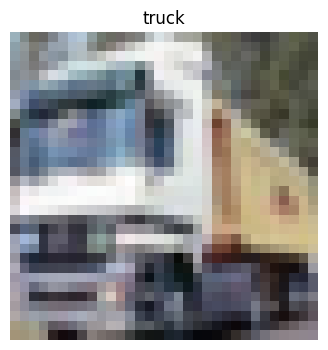

In [26]:
image, label = train_data[1]

plt.figure(figsize=(4, 4))
plt.imshow(image.permute(1, 2, 0))
plt.title(classes[label])
plt.axis("off")
plt.show()

### Funciones de training y evaluacion

In [27]:
def get_batch_accuracy(output, y, batch_size):
    pred = output.argmax(dim=1, keepdim=True)
    correct = pred.eq(y.view_as(pred)).sum().item()
    return correct / batch_size

def evaluate(_model, _data_loader, _loss_function):
    _model.eval()
    loss = 0.0
    acc = 0.0

    with torch.no_grad():
        for X_batch, y_batch in _data_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            output = _model(X_batch)
            loss += _loss_function(output, y_batch).item() * X_batch.size(0)
            acc += get_batch_accuracy(output, y_batch, X_batch.size(0)) * X_batch.size(0)

    loss = loss / len(_data_loader.dataset)
    acc = acc / len(_data_loader.dataset)

    return loss, acc

def train(_model, _train_loader, _test_loader, _criterion, _optimizer, _num_epochs):
    history = {
        "train_loss": [],
        "train_acc": [],
        "test_loss": [],
        "test_acc": []
    }

    for epoch in tqdm(range(_num_epochs), desc="Training", unit="epoch"):
        _model.train()
        train_loss = 0.0
        train_acc = 0.0

        for X_batch, y_batch in _train_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            _optimizer.zero_grad()
            output = _model(X_batch)
            loss = _criterion(output, y_batch)
            loss.backward()
            _optimizer.step()

            train_loss += loss.item() * X_batch.size(0)
            train_acc += get_batch_accuracy(output, y_batch, X_batch.size(0)) * X_batch.size(0)

        train_loss = train_loss / len(_train_loader.dataset)
        train_acc = train_acc / len(_train_loader.dataset)

        test_loss, test_acc = evaluate(_model, _test_loader, _criterion)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["test_loss"].append(test_loss)
        history["test_acc"].append(test_acc)

        print(
            f"Epoch {epoch + 1}/{_num_epochs} - "
            f"train_loss: {train_loss:.4f} - train_acc: {train_acc:.4f} - "
            f"test_loss: {test_loss:.4f} - test_acc: {test_acc:.4f}"
        )

    return history

### Modelos

In [28]:
model_1 = nn.Sequential(
    nn.Conv2d(3, 16, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2),

    nn.Conv2d(16, 32, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2),

    nn.Flatten(),
    nn.Linear(32 * 8 * 8, 128),
    nn.ReLU(),
    nn.Linear(128, 10)
).to(device)

model_2 = nn.Sequential(
    nn.Conv2d(3, 32, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2),

    nn.Conv2d(32, 64, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2),

    nn.Flatten(),
    nn.Linear(64 * 8 * 8, 256),
    nn.ReLU(),
    nn.Linear(256, 10)
).to(device)

model_3 = nn.Sequential(
    nn.Conv2d(3, 32, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2),

    nn.Conv2d(32, 64, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2),

    nn.Conv2d(64, 128, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2),

    nn.Flatten(),
    nn.Linear(128 * 4 * 4, 256),
    nn.ReLU(),
    nn.Linear(256, 10)
).to(device)

In [29]:
epochs = 15
learning_rate = 0.001

criterion = nn.CrossEntropyLoss()

optimizer_1 = Adam(model_1.parameters(), lr=learning_rate)
optimizer_2 = Adam(model_2.parameters(), lr=learning_rate)
optimizer_3 = Adam(model_3.parameters(), lr=learning_rate)

In [30]:
history_1 = train(model_1, train_loader, test_loader, criterion, optimizer_1, epochs)
history_2 = train(model_2, train_loader, test_loader, criterion, optimizer_2, epochs)
history_3 = train(model_3, train_loader, test_loader, criterion, optimizer_3, epochs)

Training:   7%|▋         | 1/15 [00:08<01:56,  8.32s/epoch]

Epoch 1/15 - train_loss: 1.5774 - train_acc: 0.4335 - test_loss: 1.3356 - test_acc: 0.5321


Training:  13%|█▎        | 2/15 [00:16<01:50,  8.53s/epoch]

Epoch 2/15 - train_loss: 1.2291 - train_acc: 0.5639 - test_loss: 1.1610 - test_acc: 0.5840


Training:  20%|██        | 3/15 [00:25<01:40,  8.41s/epoch]

...

Epoch 13/15 - train_loss: 0.1839 - train_acc: 0.9339 - test_loss: 1.1763 - test_acc: 0.7292


Training:  93%|█████████▎| 14/15 [01:50<00:07,  7.93s/epoch]

Epoch 14/15 - train_loss: 0.1569 - train_acc: 0.9444 - test_loss: 1.2536 - test_acc: 0.7276


Training: 100%|██████████| 15/15 [01:58<00:00,  7.93s/epoch]

Epoch 15/15 - train_loss: 0.1310 - train_acc: 0.9532 - test_loss: 1.3839 - test_acc: 0.7164


### Graficas

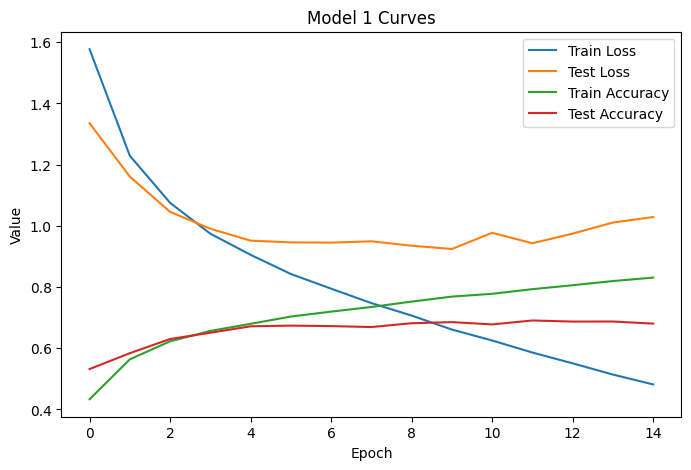

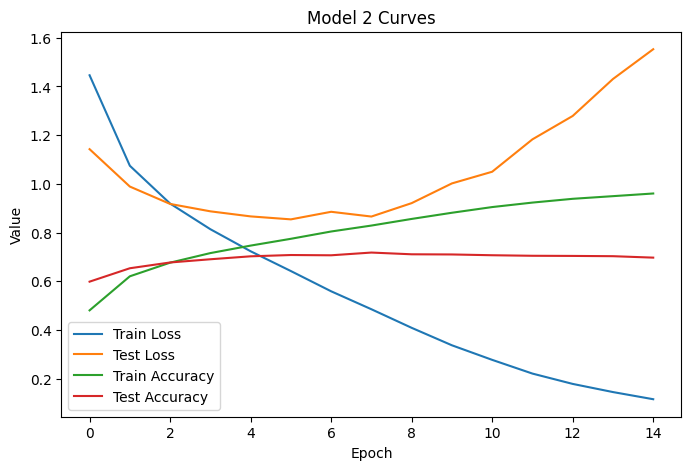

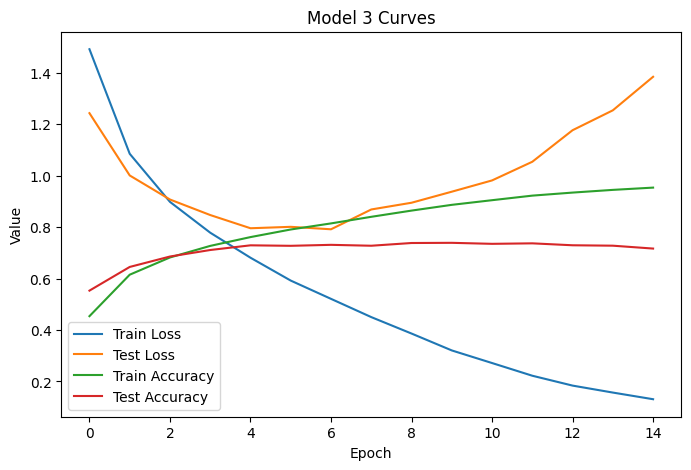

In [31]:
plt.figure(figsize=(8, 5))
plt.plot(history_1["train_loss"], label="Train Loss")
plt.plot(history_1["test_loss"], label="Test Loss")
plt.plot(history_1["train_acc"], label="Train Accuracy")
plt.plot(history_1["test_acc"], label="Test Accuracy")
plt.title("Model 1 Curves")
plt.xlabel("Epoch")
plt.ylabel("Value")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history_2["train_loss"], label="Train Loss")
plt.plot(history_2["test_loss"], label="Test Loss")
plt.plot(history_2["train_acc"], label="Train Accuracy")
plt.plot(history_2["test_acc"], label="Test Accuracy")
plt.title("Model 2 Curves")
plt.xlabel("Epoch")
plt.ylabel("Value")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history_3["train_loss"], label="Train Loss")
plt.plot(history_3["test_loss"], label="Test Loss")
plt.plot(history_3["train_acc"], label="Train Accuracy")
plt.plot(history_3["test_acc"], label="Test Accuracy")
plt.title("Model 3 Curves")
plt.xlabel("Epoch")
plt.ylabel("Value")
plt.legend()
plt.show()

In [32]:
acc_1 = history_1["test_acc"][-1]
acc_2 = history_2["test_acc"][-1]
acc_3 = history_3["test_acc"][-1]

print("Model 1 final test accuracy:", acc_1)
print("Model 2 final test accuracy:", acc_2)
print("Model 3 final test accuracy:", acc_3)

best_model = model_1
best_model_name = "Model 1"
best_model_acc = acc_1

if acc_2 > best_model_acc:
    best_model = model_2
    best_model_name = "Model 2"
    best_model_acc = acc_2

if acc_3 > best_model_acc:
    best_model = model_3
    best_model_name = "Model 3"
    best_model_acc = acc_3

best_test_loss, best_test_acc = evaluate(best_model, test_loader, criterion)

print("Best model:", best_model_name)
print("Best model test loss:", best_test_loss)
print("Best model test accuracy:", best_test_acc)

Model 1 final test accuracy: 0.6806
Model 2 final test accuracy: 0.6975
Model 3 final test accuracy: 0.7164
Best model: Model 3
Best model test loss: 1.3838610368728637
Best model test accuracy: 0.7164


### puntos extras

In [33]:
def classify_image(image_path, model):
    image_transform = transforms.Compose([
        transforms.Resize((32, 32)),
        transforms.ToTensor()
    ])

    image = Image.open(image_path).convert("RGB")
    x = image_transform(image).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        output = model(x)
        pred = output.argmax(dim=1).item()

    plt.figure(figsize=(4, 4))
    plt.imshow(image)
    plt.title(f"Predicted class: {classes[pred]}")
    plt.axis("off")
    plt.show()

    return classes[pred]

### Prueba de prediccion en imagen local 

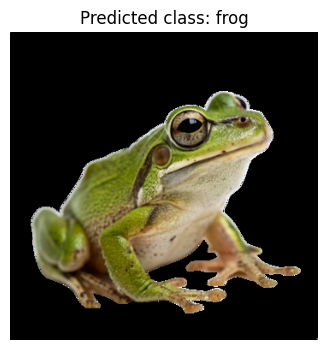

Predicted class: frog


In [34]:
image_path = "./input.png"

if os.path.exists(image_path):
    predicted_class = classify_image(image_path, best_model)
    print("Predicted class:", predicted_class)
else:
    print("No imagen detectada")

## reflexion

El mejor fue el modelo 3 con 71.64% en test. En las gráficas  se puede ver que los modelos aprendieron durante el entrenamiento, aunque después de unos pocos epochs el test loss empezó a subir y el overfitting fue bastante. Pude ver como cambiando la arquitectua a una mas profunda el modelo mejora en aprender caracteristicas.